# Analisis & Narrative Timeline: Perkembangan *Vibe Coding* di X/Twitter

Notebook ini menganalisis hasil scraping `vibecoding_relevant_10000.csv` (Playwright + filter konteks ketat) untuk menyusun **narasi perkembangan fenomena vibe coding dari masa ke masa**.

**Cakupan periode: 2025 Q1 hingga sekarang.** Data sebelum 2025-01-01 dibuang karena volumenya sangat tipis (long tail hasil scraping) dan tidak layak dijadikan dasar tren. Ubah lewat konstanta `TANGGAL_MULAI` di cell A1.

## Struktur Notebook

| Bagian | Isi |
|---|---|
| **A. Persiapan** | Setup library, definisi helper, load data, upload (bila kernel Colab) |
| **B. Pembersihan** | Batasi periode + buang artefak UI scraping (prefix tanggal, blok `Kutipan`, angka engagement) |
| **C. Profil Dataset** | Ukuran, rentang waktu, kelengkapan kolom, akun teraktif |
| **D. Kualitas Konteks** | Distribusi panjang tweet, cek apakah tweet cukup berkonteks |
| **E. Analisis Kata** | Kata terpopuler, distribusi frekuensi (pola Zipf) |
| **F. Lanskap Tools** | Perbandingan penyebutan Cursor, Windsurf, Copilot, Claude, dll |
| **G. Timeline** | Volume per bulan/kuartal, pertumbuhan, kurva adopsi kumulatif |
| **H. Deteksi Event** | Spike harian otomatis + **topik khas** yang dibahas saat spike (bukan cuma tweet terpanjang) |
| **I. Ringkasan** | Temuan kunci sebagai bahan penulisan narasi |

## Metode Deteksi Topik Spike (H2)

Untuk tiap hari lonjakan, frekuensi kata & frasa hari itu dibandingkan dengan korpus keseluruhan memakai **lift** = proporsi di hari spike / proporsi di korpus.

Kata yang muncul merata di semua hari (`vibe`, `coding`, `ai`) punya lift mendekati 1 sehingga otomatis tersaring. Yang tersisa di peringkat atas adalah **pembeda topik hari itu** — inilah petunjuk pemicu spike (rilis tool, insiden keamanan, momen viral).

## Cara Menjalankan

Jalankan **berurutan dari atas**. Setiap cell analisis memanggil `siapkan_data()` sehingga aman dijalankan mandiri tanpa `KeyError`. Jika memakai kernel Colab remote, cell A1 akan menampilkan tombol upload — upload CSV-nya, lalu lanjut ke cell A2.

In [54]:
# =============================================================================
# A1. SETUP, HELPER, & LOAD DATA
# =============================================================================
import io
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CSV_PATH = "data/raw/vibecoding_relevant_10000.csv"

# Data sebelum 2025 Q1 dibuang: volumenya sangat tipis (long tail hasil scraping)
# sehingga tidak layak dijadikan dasar narasi tren.
TANGGAL_MULAI = "2025-01-01"

TOOLS = ["cursor", "windsurf", "copilot", "claude", "replit", "lovable", "bolt", "devin"]

# --- Artefak UI hasil scraping X yang perlu dibuang -------------------------
#   prefix tanggal UI  -> "17 Jul Vibe coding ..."  /  "22dtk Vibe coding ..."
#   blok quote-tweet   -> "... Kutipan Shay Boloor @StockSavvyShay 10 Apr ..."
#   notice terjemahan  -> "Diterjemahkan dari Inggris Tampilkan yang asli"
#   angka engagement   -> "... vibecoding 9 211"  /  "... Marriage W 44 5 rb"
BULAN = r"(?:Jan|Feb|Mar|Apr|Mei|May|Jun|Jul|Agu|Aug|Sep|Okt|Oct|Nov|Des|Dec)"

STOPWORDS = {
    # Inggris
    "the", "a", "an", "and", "to", "of", "is", "in", "for", "on", "it", "this",
    "that", "with", "my", "you", "was", "are", "be", "at", "just", "so", "but",
    "have", "has", "had", "not", "or", "as", "if", "we", "your", "me", "im",
    "its", "do", "did", "does", "can", "will", "would", "up", "out", "about",
    "like", "how", "what", "when", "who", "why", "all", "more", "one", "into",
    "from", "now", "they", "them", "their", "there", "here", "then", "than",
    "been", "being", "our", "his", "her", "she", "he", "get", "got", "make",
    "made", "very", "much", "some", "any", "too", "also", "even", "still",
    "https", "http", "www", "com", "co", "amp", "rt",
    # Indonesia
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan", "ada",
    "tidak", "saya", "kamu", "kita", "juga", "bisa", "aja", "gak", "ga", "kalau",
    "kalo", "udah", "sudah", "lagi", "banget", "nya", "pada", "atau", "sama",
    "biar", "karena", "jadi", "kan", "sih", "deh", "dong", "loh", "ya", "gitu",
    "gini", "buat", "pakai", "pake", "gua", "gue", "aku", "dia", "mereka",
    # Artefak UI & nama bulan
    "kutipan", "jan", "feb", "mar", "apr", "mei", "may", "jun", "jul", "agu",
    "aug", "sep", "okt", "oct", "nov", "des", "dec", "dtk", "mnt",
}


def bersihkan_teks(teks: object) -> str:
    """Normalisasi teks tweet: hapus artefak UI X, URL, dan angka engagement."""
    t = str(teks)
    t = re.sub(r"https?://\S+", " ", t)
    t = re.sub(r"\bDiterjemahkan dari \w+(\s+Tampilkan yang asli)?", " ", t, flags=re.I)
    t = re.sub(rf"^\s*\d{{1,2}}\s*{BULAN}\b", " ", t)
    t = re.sub(r"^\s*\d+\s*(dtk|mnt|jam|j|h)\b", " ", t, flags=re.I)
    t = re.sub(r"\bKutipan\b.*$", " ", t, flags=re.S)
    t = re.sub(r"(\s+\d+([.,]\d+)?(\s*(rb|jt|k|m))?)+\s*$", " ", t, flags=re.I)
    return re.sub(r"\s+", " ", t).strip()


def siapkan_data(d: pd.DataFrame, paksa: bool = False) -> pd.DataFrame:
    """Pastikan kolom turunan tersedia dan data dibatasi mulai TANGGAL_MULAI.

    Dipanggil di awal tiap bagian analisis supaya setiap cell dapat dijalankan
    mandiri tanpa tergantung urutan eksekusi cell sebelumnya. Idempoten.
    """
    if not pd.api.types.is_datetime64_any_dtype(d.get("created_at")):
        d["created_at"] = pd.to_datetime(d["created_at"], errors="coerce", utc=True)
        d = d.dropna(subset=["created_at"])
    batas = pd.Timestamp(TANGGAL_MULAI, tz="UTC")
    d = d[d["created_at"] >= batas].sort_values("created_at").reset_index(drop=True)
    if paksa or "text_clean" not in d.columns:
        d["text_clean"] = d["text"].fillna("").map(bersihkan_teks)
    if paksa or "word_count" not in d.columns:
        d["word_count"] = d["text_clean"].str.split().map(len)
    return d


def tokenisasi(teks: str) -> list:
    """Pecah teks jadi token bermakna (buang stopword & kata <= 2 huruf)."""
    return [w for w in re.findall(r"[a-zA-Z']+", str(teks).lower())
            if w not in STOPWORDS and len(w) > 2]


def hitung_frekuensi(d: pd.DataFrame) -> Counter:
    """Frekuensi kata tunggal dari kolom text_clean."""
    return Counter(w for teks in d["text_clean"] for w in tokenisasi(teks))


def hitung_bigram(d: pd.DataFrame) -> Counter:
    """Frekuensi pasangan kata berurutan (tidak melewati batas antar-tweet)."""
    hasil = Counter()
    for teks in d["text_clean"]:
        tok = tokenisasi(teks)
        hasil.update(f"{a} {b}" for a, b in zip(tok, tok[1:]))
    return hasil


def topik_khas(freq_subset: Counter, freq_global: Counter,
               min_muncul: int = 3, n: int = 10) -> list:
    """Istilah paling KHAS pada subset dibanding korpus global.

    Memakai lift = proporsi di subset / proporsi di korpus global. Kata yang
    sering muncul di mana-mana (mis. 'vibe', 'coding') otomatis tersaring
    karena lift-nya mendekati 1, sehingga yang tersisa adalah pembeda topik.
    """
    total_sub = sum(freq_subset.values()) or 1
    total_glob = sum(freq_global.values()) or 1
    skor = []
    for istilah, jumlah in freq_subset.items():
        if jumlah < min_muncul:
            continue
        p_sub = jumlah / total_sub
        p_glob = freq_global.get(istilah, 0) / total_glob
        skor.append((istilah, jumlah, p_sub / (p_glob + 1e-12)))
    skor.sort(key=lambda x: x[2], reverse=True)
    return skor[:n]


# --- Load data --------------------------------------------------------------
df = None
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Data terbaca dari filesystem lokal: {len(df):,} baris")
else:
    print("File tidak ditemukan di runtime ini (kemungkinan kernel Colab remote).")
    print("Klik tombol Upload di bawah, pilih file CSV, lalu jalankan CELL BERIKUTNYA.")
    import ipywidgets as widgets

    uploader = widgets.FileUpload(accept=".csv", multiple=False)
    display(uploader)

File tidak ditemukan di runtime ini (kemungkinan kernel Colab remote).
Klik tombol Upload di bawah, pilih file CSV, lalu jalankan CELL BERIKUTNYA.


FileUpload(value={}, accept='.csv', description='Upload')

In [55]:
# =============================================================================
# A2. PROSES FILE UPLOAD  (hanya perlu bila kernel Colab remote)
# =============================================================================
# Kalau data sudah terbaca di cell A1, cell ini otomatis dilewati tanpa error.
if df is None:
    if "uploader" not in globals() or not uploader.value:
        print("Belum ada file yang diupload.")
        print("Klik tombol Upload di cell A1, pilih file CSV, lalu jalankan cell ini lagi.")
    else:
        uploaded = uploader.value
        if isinstance(uploaded, dict):        # ipywidgets v7
            filename, info = next(iter(uploaded.items()))
        else:                                 # ipywidgets v8+
            info = uploaded[0]
            filename = info["name"]

        df = pd.read_csv(io.BytesIO(bytes(info["content"])))
        print(f"Berhasil membaca '{filename}': {len(df):,} baris")

if df is not None:
    df = siapkan_data(df)
    print(f"Data siap  : {len(df):,} baris")
    print(f"Rentang    : {df['created_at'].min().date()} -> {df['created_at'].max().date()}")
    display(df.head(3))

Berhasil membaca 'vibecoding_relevant_10000.csv': 10,000 baris
Data siap  : 9,997 baris
Rentang    : 2025-02-02 -> 2026-07-21


,collected_at,date_window_start,date_window_end,search_query,post_url,username,displayname,created_at,text,reply_count,repost_count,like_count,view_count,text_clean,word_count
0,2026-07-21T15:09:11.988149+00:00,2025-01-31,2025-02-07,"((""vibe coding"" OR vibecoding) (app OR website OR project OR startup)) since:2025-01-31 until:20...",https://x.com/karpathy/status/1886192184808149383,karpathy,Andrej Karpathy,2025-02-02 23:17:15+00:00,"Diterjemahkan dari Inggris Tampilkan yang asli Ada jenis pemrograman baru yang saya sebut ""vibe ...",NaN,NaN,NaN,NaN,"Ada jenis pemrograman baru yang saya sebut ""vibe coding"", di mana kamu sepenuhnya menyerah pada ...",41
1,2026-07-21T15:09:11.937097+00:00,2025-01-31,2025-02-07,"((""vibe coding"" OR vibecoding) (app OR website OR project OR startup)) since:2025-01-31 until:20...",https://x.com/luizfgparreira/status/1886204681766027415,luizfgparreira,luiz - bipa.app,2025-02-03 00:06:54+00:00,I have built a few app ideas in my spare time and one internal tool @usebipa using exactly this ...,NaN,NaN,NaN,NaN,I have built a few app ideas in my spare time and one internal tool @usebipa using exactly this ...,48
2,2026-07-21T19:59:05.048526+00:00,2025-01-31,2025-02-07,"((""vibe coding"" OR vibecoding) (cursor OR windsurf OR copilot OR claude OR replit OR lovable OR ...",https://x.com/clarrrentt/status/1886228964479483929,clarrrentt,𝗰𝗹𝗮𝗿𝗲𝗻𝘁,2025-02-03 01:43:24+00:00,poasting on X is part of my vibe coding pipeline while i wait for chats to load with cursor sonn...,NaN,NaN,NaN,NaN,poasting on X is part of my vibe coding pipeline while i wait for chats to load with cursor sonn...,21


In [56]:
# =============================================================================
# B. PEMBERSIHAN TEKS & PEMBATASAN PERIODE
# =============================================================================
# 1. Buang data sebelum TANGGAL_MULAI (2025-01-01) -> dilakukan di siapkan_data()
# 2. Terapkan bersihkan_teks() secara paksa
# 3. Buang baris yang jadi terlalu pendek (<3 kata) setelah dibersihkan
mentah = len(df)
periode_awal = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
jumlah_pra2025 = int((periode_awal < pd.Timestamp(TANGGAL_MULAI, tz="UTC")).sum())

df = siapkan_data(df, paksa=True)
sebelum_filter_kata = len(df)
df = df[df["word_count"] >= 3].reset_index(drop=True)

print(f"Baris mentah                                   : {mentah:,}")
print(f"Dibuang karena < {TANGGAL_MULAI} (pra-2025 Q1)    : {jumlah_pra2025:,}")
print(f"Dibuang karena kosong / <3 kata                : {sebelum_filter_kata - len(df):,}")
print(f"Data siap dianalisis                           : {len(df):,} baris")
print(f"Rentang waktu final                            : "
      f"{df['created_at'].min().date()} -> {df['created_at'].max().date()}")
print()

print("Contoh hasil pembersihan:")
for asli, bersih in zip(df["text"].head(3), df["text_clean"].head(3)):
    print("  ASLI   :", str(asli)[:110])
    print("  BERSIH :", bersih[:110])
    print("  " + "-" * 76)

Baris mentah                                   : 9,997
Dibuang karena < 2025-01-01 (pra-2025 Q1)    : 0
Dibuang karena kosong / <3 kata                : 36
Data siap dianalisis                           : 9,961 baris
Rentang waktu final                            : 2025-02-02 -> 2026-07-21

Contoh hasil pembersihan:
  ASLI   : Diterjemahkan dari Inggris Tampilkan yang asli Ada jenis pemrograman baru yang saya sebut "vibe coding", di ma
  BERSIH : Ada jenis pemrograman baru yang saya sebut "vibe coding", di mana kamu sepenuhnya menyerah pada getaran itu, m
  ----------------------------------------------------------------------------
  ASLI   : I have built a few app ideas in my spare time and one internal tool @usebipa using exactly this “vibe coding”,
  BERSIH : I have built a few app ideas in my spare time and one internal tool @usebipa using exactly this “vibe coding”,
  ----------------------------------------------------------------------------
  ASLI   : poasting on X is part of 

In [57]:
# =============================================================================
# C. PROFIL DATASET
# =============================================================================
print("--- Ukuran & Cakupan ---")
print(f"Jumlah tweet          : {len(df):,}")
print(f"Jumlah kolom          : {df.shape[1]}")
print(f"Rentang waktu         : {df['created_at'].min().date()} -> {df['created_at'].max().date()}")
print(f"Rentang hari          : {(df['created_at'].max() - df['created_at'].min()).days} hari")
print(f"Akun unik             : {df['username'].nunique():,}")
print(f"Duplikat URL tersisa  : {df['post_url'].duplicated().sum()}")
print()

print("--- Kelengkapan Data per Kolom (% terisi) ---")
kelengkapan = (df.notna().mean() * 100).round(1).sort_values(ascending=False)
print(kelengkapan.to_string())
print()

print("--- 10 Akun Paling Sering Muncul ---")
print(df["username"].value_counts().head(10).to_string())

--- Ukuran & Cakupan ---
Jumlah tweet          : 9,961
Jumlah kolom          : 15
Rentang waktu         : 2025-02-02 -> 2026-07-21
Rentang hari          : 533 hari
Akun unik             : 8,197
Duplikat URL tersisa  : 0

--- Kelengkapan Data per Kolom (% terisi) ---
collected_at         100.0
date_window_start    100.0
date_window_end      100.0
search_query         100.0
post_url             100.0
username             100.0
displayname          100.0
created_at           100.0
text                 100.0
text_clean           100.0
word_count           100.0
repost_count           0.0
reply_count            0.0
view_count             0.0
like_count             0.0

--- 10 Akun Paling Sering Muncul ---
username
bridgemindai      39
rileybrown        21
tristanbob        19
0rdlibrary        19
meta_alchemist    19
AskPerplexity     18
_akhaliq          18
PrajwalTomar_     16
thisiskp_         15
jasonlk           15


--- Statistik Jumlah Kata per Tweet ---
count    9961.0
mean       34.9
std        17.0
min         3.0
25%        22.0
50%        38.0
75%        47.0
max       757.0

--- Statistik Jumlah Karakter per Tweet ---
count    9961.0
mean      206.5
std        98.4
min        14.0
25%       136.0
50%       230.0
75%       274.0
max      4268.0

--- Distribusi per Rentang Jumlah Kata ---
            jumlah_tweet  persen
word_count                      
1-3                   45     0.5
4-5                  142     1.4
6-10                 630     6.3
11-20               1435    14.4
21-30               1410    14.2
31-50               5052    50.7
51-100              1245    12.5
100+                   2     0.0


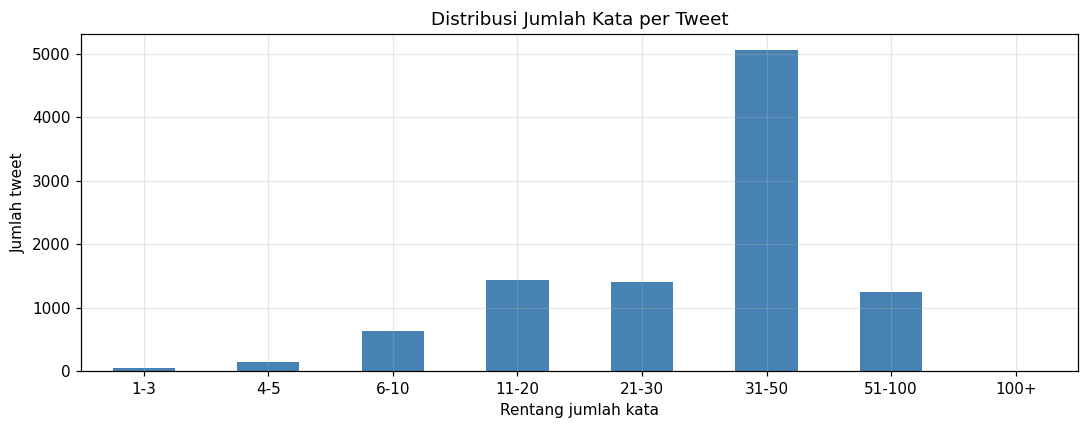

Tweet sangat pendek (<=5 kata) : 1.9%
Median panjang tweet           : 38 kata
Kesimpulan                     : konteks memadai


In [58]:
# =============================================================================
# D. KUALITAS KONTEKS  -  distribusi panjang tweet
# =============================================================================
# Tujuan: memastikan tweet benar-benar berisi konteks, bukan sekadar keyword spam.
df = siapkan_data(df)

print("--- Statistik Jumlah Kata per Tweet ---")
print(df["word_count"].describe().round(1).to_string())
print()
print("--- Statistik Jumlah Karakter per Tweet ---")
print(df["text_clean"].str.len().describe().round(1).to_string())
print()

BINS = [0, 3, 5, 10, 20, 30, 50, 100, max(101, int(df["word_count"].max()) + 1)]
LABELS = ["1-3", "4-5", "6-10", "11-20", "21-30", "31-50", "51-100", "100+"]
bucket_kata = pd.cut(df["word_count"], bins=BINS, labels=LABELS, right=True)

bucket = bucket_kata.value_counts().reindex(LABELS).fillna(0).astype(int)
ringkas = pd.DataFrame({"jumlah_tweet": bucket, "persen": (bucket / len(df) * 100).round(1)})
print("--- Distribusi per Rentang Jumlah Kata ---")
print(ringkas.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
bucket.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribusi Jumlah Kata per Tweet")
ax.set_xlabel("Rentang jumlah kata")
ax.set_ylabel("Jumlah tweet")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

pct_pendek = (df["word_count"] <= 5).mean() * 100
print(f"Tweet sangat pendek (<=5 kata) : {pct_pendek:.1f}%")
print(f"Median panjang tweet           : {df['word_count'].median():.0f} kata")
print("Kesimpulan                     :",
      "konteks memadai" if pct_pendek < 10 else "banyak tweet minim konteks, perlu filter tambahan")

In [59]:
# =============================================================================
# D2. SAMPEL TWEET  -  terpendek vs terpanjang
# =============================================================================
# Terpendek dipakai untuk mengecek sisa noise; terpanjang biasanya paling kaya konteks.
df = siapkan_data(df)

print("=" * 78)
print("10 TWEET TERPENDEK  (indikator sisa noise)")
print("=" * 78)
for teks in df.nsmallest(10, "word_count")["text_clean"]:
    print(" -", teks)

print()
print("=" * 78)
print("10 TWEET TERPANJANG  (paling kaya konteks)")
print("=" * 78)
for teks in df.nlargest(10, "word_count")["text_clean"]:
    print(" -", teks[:200], "...")

10 TWEET TERPENDEK  (indikator sisa noise)
 - Vibe coding、アイデア→コーディング→設計や仕様は後から。受託やチーム開発だと難しい面もあるけど、Cursor での自然言語プログラミングにはぴったりかもしれない。
 - "rules" "vibe coding"
 - vibe coding stack
 - “Vibe coding” FML
 - currently vibe coding
 - vibe coding it
 - Ramon vibe coding
 - Vibe coding already
 - Keep vibe coding!
 - Vibe coding king

10 TWEET TERPANJANG  (paling kaya konteks)
 - Vibe coding without understanding can be dangerous! I managed to spot the bug Grok3 AI insisted is correct. It's great that it found the bug once I pointed it out. Not perfect, but still impressive! # ...
 - Is Vibe Coding creating the next wave of billion-dollar startups... or the next wave of abandoned apps? Anyone can build. Distribution is still hard. Marketing is still hard. Retention is still hard.  ...
 - Do you think vibe coding onchain apps is valuable? We open this feature https:// github.com/DexKit/dexkit- monorepo/issues/546 … to start implementing it after our current features. Let me know what y ...
 - 

--- Top 30 Kata ---
  1. vibe               10,006
  2. coding              9,926
  3. app                 2,346
  4. code                2,329
  5. vibecoding          1,876
  6. claude              1,501
  7. build               1,297
  8. building              945
  9. cursor                922
 10. using                 782
 11. new                   774
 12. people                737
 13. apps                  717
 14. tools                 708
 15. project               694
 16. use                   669
 17. real                  659
 18. built                 655
 19. time                  650
 20. it's                  619
 21. first                 564
 22. software              536
 23. day                   532
 24. prompt                523
 25. agent                 501
 26. i'm                   493
 27. think                 487
 28. lovable               466
 29. web                   459
 30. need                  447


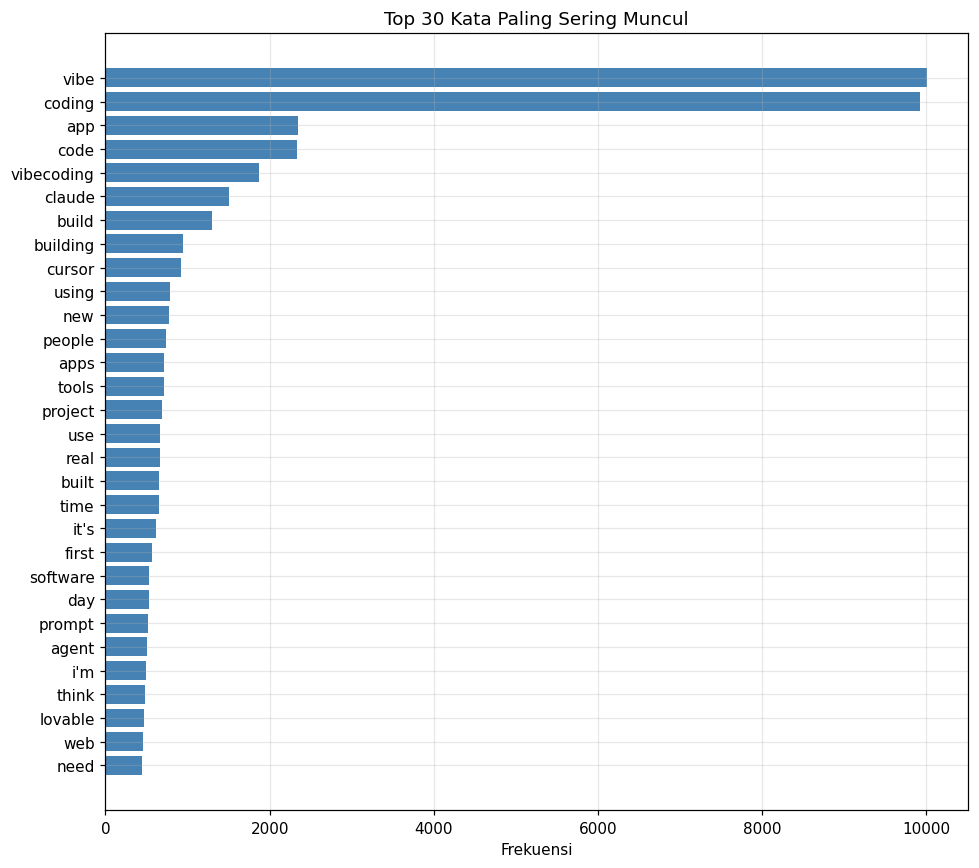

In [60]:
# =============================================================================
# E1. KATA PALING SERING MUNCUL
# =============================================================================
# STOPWORDS & hitung_frekuensi() didefinisikan di cell A1.
df = siapkan_data(df)
frekuensi = hitung_frekuensi(df)

TOP_N = 30
top_kata = frekuensi.most_common(TOP_N)

print(f"--- Top {TOP_N} Kata ---")
for i, (w, c) in enumerate(top_kata, 1):
    print(f"{i:>3}. {w:<18} {c:>6,}")

label, nilai = zip(*top_kata)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(label[::-1], nilai[::-1], color="steelblue")
ax.set_title(f"Top {TOP_N} Kata Paling Sering Muncul")
ax.set_xlabel("Frekuensi")
plt.tight_layout()
plt.show()

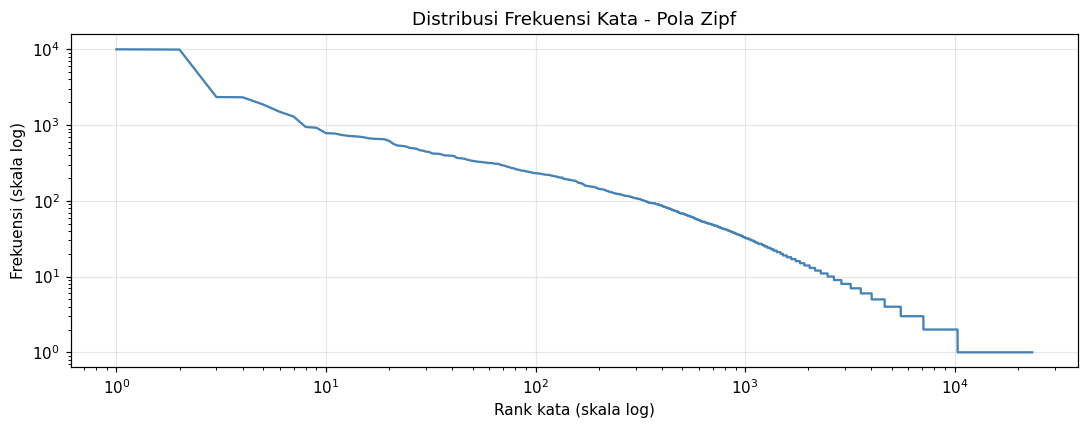

Total kata unik                     : 23,414
Total kemunculan kata (non-stopword): 206,132
Kata yang hanya muncul 1x           : 13,104 (56.0%)

--- Statistik Frekuensi per Kata ---
count    23414.0
mean         8.8
std        101.3
min          1.0
25%          1.0
50%          1.0
75%          3.0
max      10006.0


In [61]:
# =============================================================================
# E2. DISTRIBUSI FREKUENSI KATA  (pola Zipf)
# =============================================================================
# Sedikit kata dipakai sangat sering, sangat banyak kata hanya muncul sekali.
df = siapkan_data(df)
if "frekuensi" not in globals():
    frekuensi = hitung_frekuensi(df)

freqs = sorted(frekuensi.values(), reverse=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(freqs) + 1), freqs, color="steelblue")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rank kata (skala log)")
ax.set_ylabel("Frekuensi (skala log)")
ax.set_title("Distribusi Frekuensi Kata - Pola Zipf")
plt.tight_layout()
plt.show()

sekali = sum(1 for f in freqs if f == 1)
print(f"Total kata unik                     : {len(frekuensi):,}")
print(f"Total kemunculan kata (non-stopword): {sum(freqs):,}")
print(f"Kata yang hanya muncul 1x           : {sekali:,} ({sekali / len(frekuensi) * 100:.1f}%)")
print()
print("--- Statistik Frekuensi per Kata ---")
print(pd.Series(freqs).describe().round(1).to_string())

--- Penyebutan Tools dalam Dataset ---
          jumlah_tweet  persen_dari_total
claude            1247              12.52
cursor             711               7.14
lovable            375               3.76
replit             343               3.44
bolt               103               1.03
copilot             98               0.98
windsurf            74               0.74
devin                8               0.08

Tweet yang menyebut minimal 1 tool : 2,353 (23.6%)


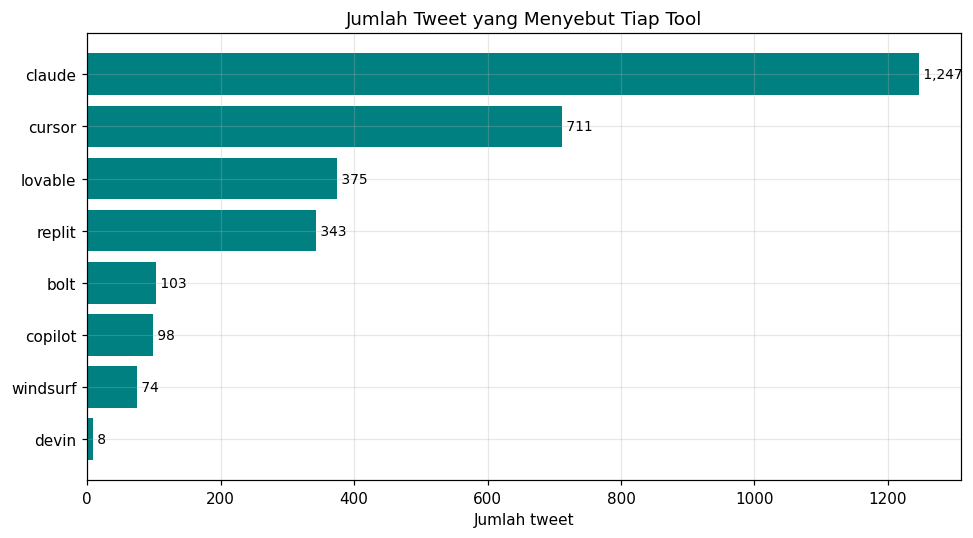

In [62]:
# =============================================================================
# F. LANSKAP TOOLS AI CODING
# =============================================================================
# Daftar TOOLS didefinisikan di cell A1 agar dipakai konsisten oleh bagian H2.
df = siapkan_data(df)

teks_lower = df["text_clean"].str.lower()
mask_tool = pd.DataFrame({
    t: teks_lower.str.contains(rf"\b{re.escape(t)}\b", regex=True) for t in TOOLS
})

tool_df = (
    pd.DataFrame({
        "jumlah_tweet": mask_tool.sum().astype(int),
        "persen_dari_total": (mask_tool.mean() * 100).round(2),
    })
    .sort_values("jumlah_tweet", ascending=False)
)

print("--- Penyebutan Tools dalam Dataset ---")
print(tool_df.to_string())
print()
print(f"Tweet yang menyebut minimal 1 tool : {int(mask_tool.any(axis=1).sum()):,} "
      f"({mask_tool.any(axis=1).mean() * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tool_df.index[::-1], tool_df["jumlah_tweet"][::-1], color="teal")
ax.set_title("Jumlah Tweet yang Menyebut Tiap Tool")
ax.set_xlabel("Jumlah tweet")
for y, v in enumerate(tool_df["jumlah_tweet"][::-1]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_553/3708555254.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["bulan"] = df["created_at"].dt.to_period("M")
/tmp/ipykernel_553/3708555254.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["kuartal"] = df["created_at"].dt.to_period("Q")


Jumlah bulan dengan data : 18

--- Volume per Kuartal ---
kuartal
2025Q1    1313
2025Q2    1139
2025Q3    2329
2025Q4     936
2026Q1    1682
2026Q2    1701
2026Q3     861
Freq: Q-DEC


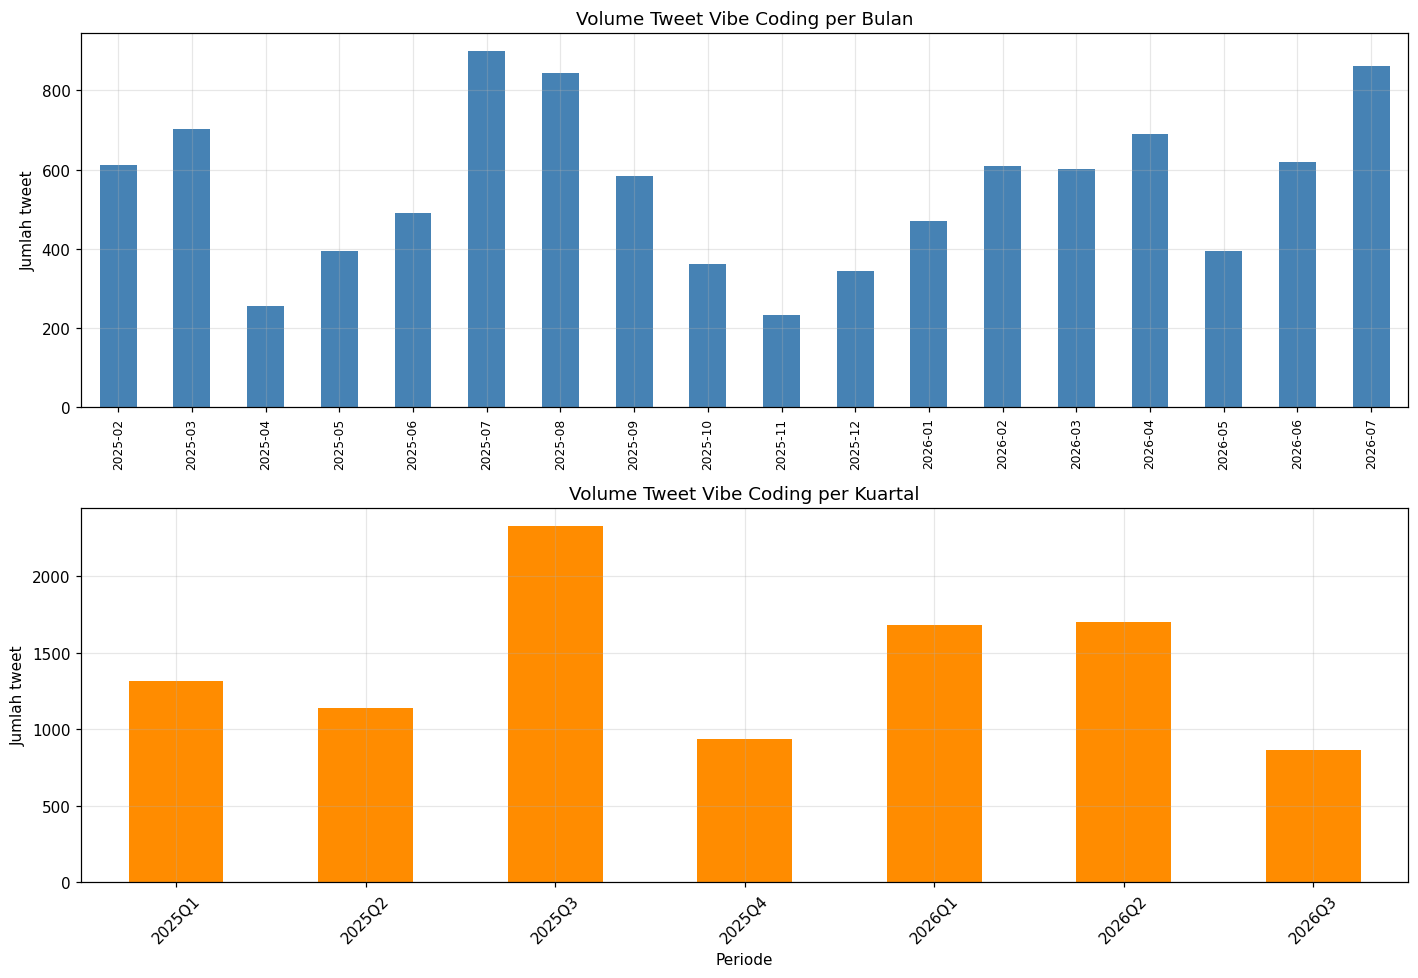

In [63]:
# =============================================================================
# G1. TIMELINE VOLUME  -  per bulan & per kuartal
# =============================================================================
df = siapkan_data(df)
df["bulan"] = df["created_at"].dt.to_period("M")
df["kuartal"] = df["created_at"].dt.to_period("Q")

bulanan = df.groupby("bulan").size()
kuartalan = df.groupby("kuartal").size()

print(f"Jumlah bulan dengan data : {len(bulanan)}")
print()
print("--- Volume per Kuartal ---")
print(kuartalan.to_string())

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

bulanan.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Volume Tweet Vibe Coding per Bulan")
axes[0].set_xlabel("")
axes[0].set_ylabel("Jumlah tweet")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)

kuartalan.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Volume Tweet Vibe Coding per Kuartal")
axes[1].set_xlabel("Periode")
axes[1].set_ylabel("Jumlah tweet")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_553/3693038441.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bulanan = df.groupby(df["created_at"].dt.to_period("M")).size()


--- Volume Bulanan & Pertumbuhan ---
            jumlah  pertumbuhan_%  kumulatif  persen_dari_total
created_at                                                     
2025-02        611            NaN        611                6.1
2025-03        702           14.9       1313                7.0
2025-04        254          -63.8       1567                2.5
2025-05        395           55.5       1962                4.0
2025-06        490           24.1       2452                4.9
2025-07        900           83.7       3352                9.0
2025-08        845           -6.1       4197                8.5
2025-09        584          -30.9       4781                5.9
2025-10        360          -38.4       5141                3.6
2025-11        232          -35.6       5373                2.3
2025-12        344           48.3       5717                3.5
2026-01        470           36.6       6187                4.7
2026-02        610           29.8       6797                6.1
202

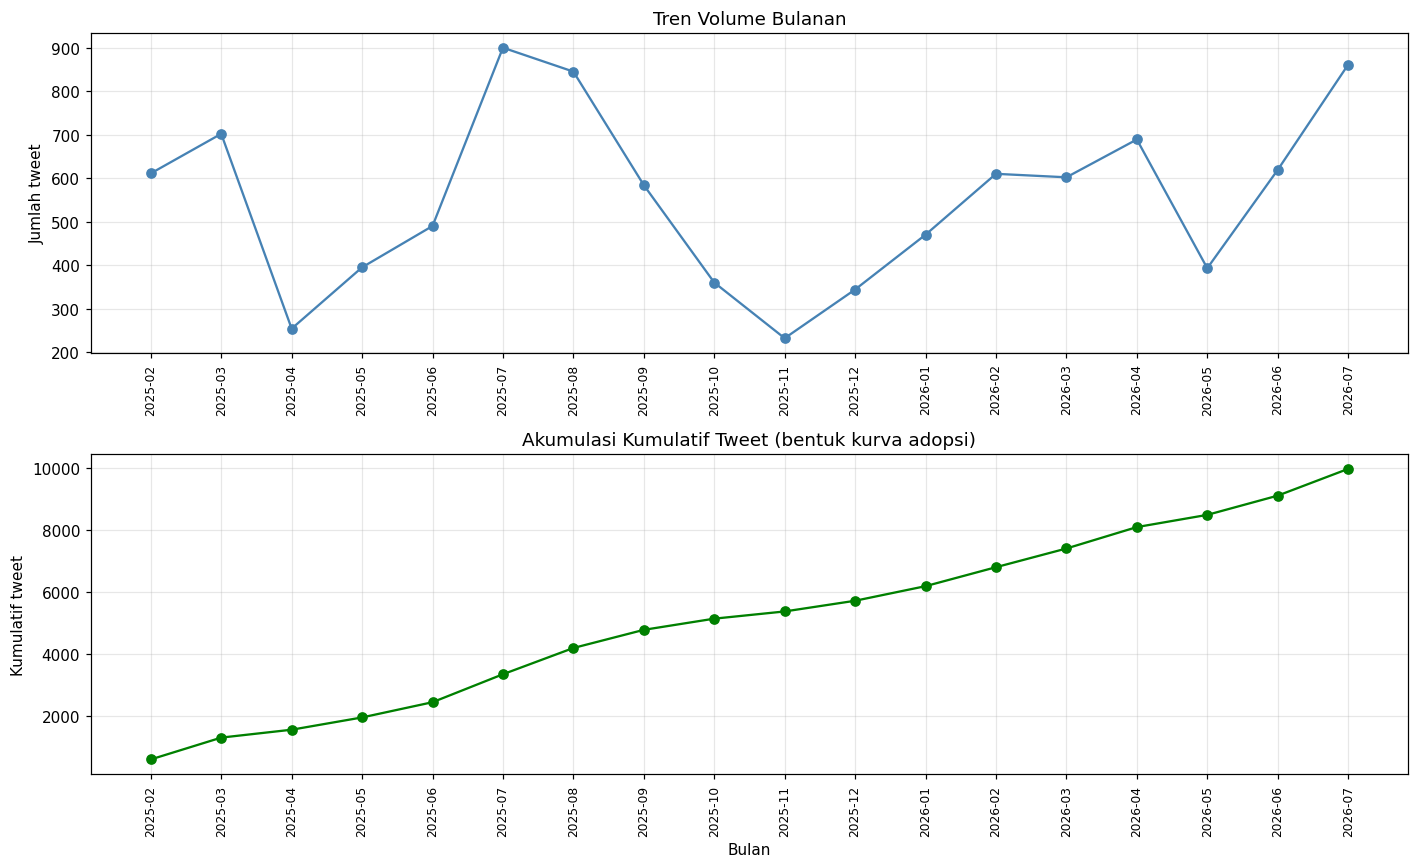

Bulan dengan volume tertinggi : 2025-07 (900 tweet)
Lonjakan pertumbuhan terbesar : 2025-07 (+84%)


In [64]:
# =============================================================================
# G2. PERTUMBUHAN & KURVA ADOPSI KUMULATIF
# =============================================================================
df = siapkan_data(df)
bulanan = df.groupby(df["created_at"].dt.to_period("M")).size()

tren = bulanan.to_frame("jumlah")
tren["pertumbuhan_%"] = tren["jumlah"].pct_change().mul(100).round(1)
tren["kumulatif"] = tren["jumlah"].cumsum()
tren["persen_dari_total"] = (tren["jumlah"] / tren["jumlah"].sum() * 100).round(1)

print("--- Volume Bulanan & Pertumbuhan ---")
print(tren.to_string())

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
x = range(len(tren))
xlabel = [str(m) for m in tren.index]

axes[0].plot(x, tren["jumlah"], marker="o", color="steelblue")
axes[0].set_title("Tren Volume Bulanan")
axes[0].set_ylabel("Jumlah tweet")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(xlabel, rotation=90, fontsize=8)

axes[1].plot(x, tren["kumulatif"], marker="o", color="green")
axes[1].set_title("Akumulasi Kumulatif Tweet (bentuk kurva adopsi)")
axes[1].set_ylabel("Kumulatif tweet")
axes[1].set_xlabel("Bulan")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(xlabel, rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

puncak = tren["jumlah"].idxmax()
print(f"Bulan dengan volume tertinggi : {puncak} ({tren.loc[puncak, 'jumlah']:,} tweet)")
tumbuh = tren["pertumbuhan_%"].idxmax()
print(f"Lonjakan pertumbuhan terbesar : {tumbuh} (+{tren.loc[tumbuh, 'pertumbuhan_%']:.0f}%)")

Hari terdeteksi spike (z > 2.0) : 73

--- 15 Spike Terbesar (kandidat event) ---
2025-03-06    196 tweet   (z = 3.3)
2025-03-13    173 tweet   (z = 2.6)
2025-07-24    178 tweet   (z = 2.9)
2025-07-31    172 tweet   (z = 2.7)
2025-08-07    175 tweet   (z = 2.8)
2025-08-14    176 tweet   (z = 2.8)
2025-08-21    175 tweet   (z = 2.8)
2025-08-28    205 tweet   (z = 3.0)
2025-09-04    205 tweet   (z = 2.8)
2026-03-26    175 tweet   (z = 2.9)
2026-04-09    187 tweet   (z = 3.2)
2026-06-18    177 tweet   (z = 3.0)
2026-07-09    175 tweet   (z = 3.1)
2026-07-16    280 tweet   (z = 2.6)
2026-07-21    268 tweet   (z = 2.1)


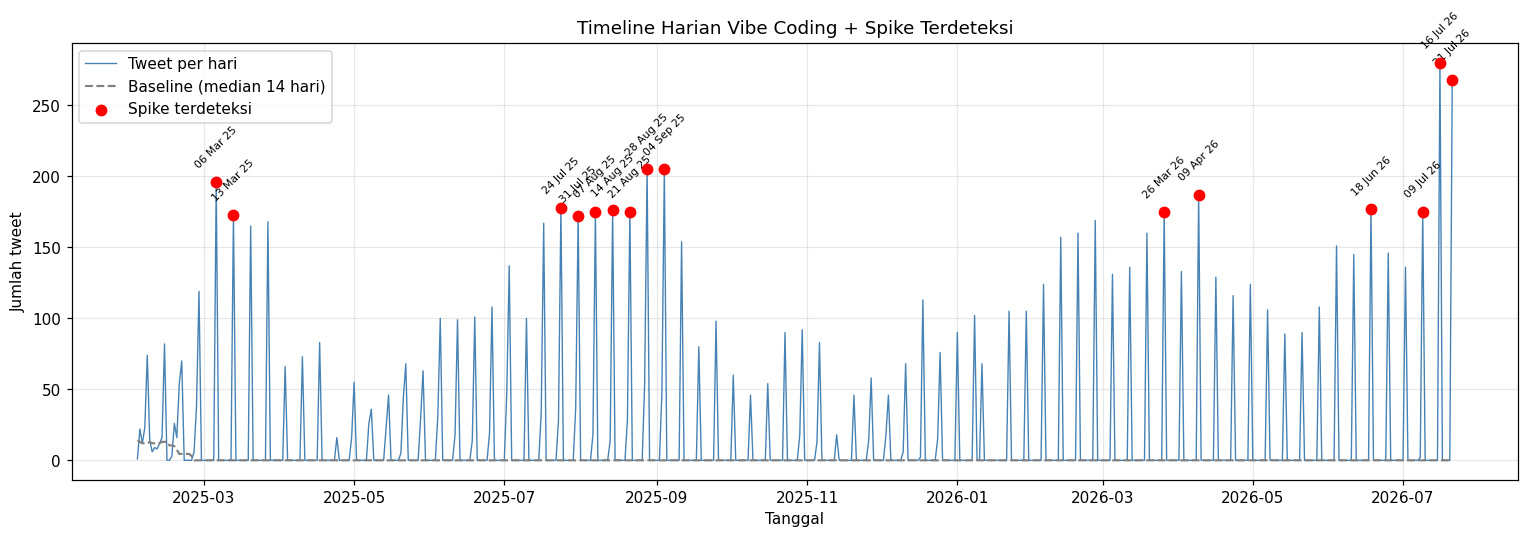

In [65]:
# =============================================================================
# H1. DETEKSI SPIKE HARIAN  -  kandidat event (rilis tool / momen viral)
# =============================================================================
# Metode: bandingkan volume harian terhadap baseline rolling median 14 hari (z-score).
df = siapkan_data(df)

harian = df.groupby(df["created_at"].dt.date).size()
harian.index = pd.to_datetime(harian.index)
harian = harian.asfreq("D", fill_value=0)

baseline = harian.rolling(14, center=True, min_periods=3).median()
sebaran = harian.rolling(14, center=True, min_periods=3).std().replace(0, 1)
z = (harian - baseline) / sebaran

SPIKE_Z = 2.0
spike = harian[(z > SPIKE_Z) & (harian > harian.median() * 1.5)]
top_spike = spike.sort_values(ascending=False).head(15).sort_index()

print(f"Hari terdeteksi spike (z > {SPIKE_Z}) : {len(spike)}")
print()
print("--- 15 Spike Terbesar (kandidat event) ---")
for tgl, n in top_spike.items():
    print(f"{tgl.date()}   {n:>4} tweet   (z = {z[tgl]:.1f})")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(harian.index, harian.values, linewidth=0.9, color="steelblue", label="Tweet per hari")
ax.plot(baseline.index, baseline.values, linewidth=1.4, linestyle="--", color="gray",
        label="Baseline (median 14 hari)")
ax.scatter(top_spike.index, top_spike.values, color="red", s=45, zorder=5, label="Spike terdeteksi")
for tgl, n in top_spike.items():
    ax.annotate(tgl.strftime("%d %b %y"), (tgl, n), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7, rotation=45)
ax.set_title("Timeline Harian Vibe Coding + Spike Terdeteksi")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah tweet")
ax.legend()
plt.tight_layout()
plt.show()

In [66]:
# =============================================================================
# H2. APA YANG DIBAHAS SAAT SPIKE  -  topik khas per hari lonjakan
# =============================================================================
# Pendekatan: untuk tiap hari spike, bandingkan frekuensi kata & frasa hari itu
# terhadap korpus keseluruhan (lift). Kata yang selalu muncul di mana-mana
# ('vibe', 'coding', 'ai') tersaring otomatis, sehingga yang tampil adalah
# pembeda topik hari itu -> inilah petunjuk pemicu spike.
df = siapkan_data(df)

if "top_spike" not in globals():
    print("Jalankan cell H1 lebih dulu untuk menghitung top_spike.")
else:
    frek_global = hitung_frekuensi(df)
    bigram_global = hitung_bigram(df)

    ringkasan_spike = []

    for tgl in top_spike.index:
        hari = df[df["created_at"].dt.date == tgl.date()]
        if hari.empty:
            continue

        kata_khas = topik_khas(hitung_frekuensi(hari), frek_global, min_muncul=3, n=10)
        frasa_khas = topik_khas(hitung_bigram(hari), bigram_global, min_muncul=2, n=6)

        teks_hari = hari["text_clean"].str.lower()
        tool_hari = {
            t: int(teks_hari.str.contains(rf"\b{re.escape(t)}\b", regex=True).sum())
            for t in TOOLS
        }
        tool_hari = {k: v for k, v in sorted(tool_hari.items(), key=lambda kv: -kv[1]) if v > 0}

        print("=" * 78)
        print(f"{tgl.strftime('%d %B %Y')}   -   {len(hari)} tweet")
        print("=" * 78)

        print("Kata paling khas hari ini (jumlah | lift vs korpus):")
        for istilah, jumlah, lift in kata_khas:
            print(f"   {istilah:<20} {jumlah:>4}x   lift {lift:>6.1f}")

        if frasa_khas:
            print("\nFrasa (bigram) paling khas:")
            for istilah, jumlah, lift in frasa_khas:
                print(f"   {istilah:<28} {jumlah:>3}x   lift {lift:>6.1f}")

        if tool_hari:
            print("\nTool yang disebut :",
                  ", ".join(f"{k} ({v})" for k, v in list(tool_hari.items())[:6]))

        print("\nTweet paling sering di-echo (mewakili topik dominan):")
        kata_kunci = {istilah for istilah, _, _ in kata_khas[:5]}
        hari = hari.assign(
            skor_topik=hari["text_clean"].str.lower().map(
                lambda t: sum(1 for k in kata_kunci if k in t)
            )
        )
        for teks in hari.sort_values(["skor_topik", "word_count"], ascending=False)["text_clean"].head(4):
            print("   -", teks[:180])
        print()

        ringkasan_spike.append({
            "tanggal": tgl.date(),
            "jumlah_tweet": len(hari),
            "topik_khas": ", ".join(i for i, _, _ in kata_khas[:5]),
            "tool_dominan": next(iter(tool_hari), "-"),
        })

    print("=" * 78)
    print("TABEL RINGKAS SPIKE  (bahan timeline narasi)")
    print("=" * 78)
    print(pd.DataFrame(ringkasan_spike).to_string(index=False))

06 March 2025   -   196 tweet
Kata paling khas hari ini (jumlah | lift vs korpus):
   dominic                 3x   lift   48.3
   gaining                 3x   lift   24.2
   dfinity                 3x   lift   24.2
   complaining             3x   lift   19.3
   nearly                  3x   lift   17.6
   coined                  6x   lift   12.9
   self                    8x   lift   10.7
   iterating               3x   lift   10.7
   andrej                  8x   lift    9.7
   coffee                  3x   lift    8.4

Frasa (bigram) paling khas:
   self writing                   7x   lift   65.3
   writing internet               7x   lift   65.3
   founder mode                   3x   lift   65.3
   assisted approach              2x   lift   65.3
   ideas natural                  2x   lift   65.3
   openai andrey                  2x   lift   65.3

Tool yang disebut : claude (13), cursor (10), lovable (4), windsurf (3), replit (3), copilot (1)

Tweet paling sering di-echo (mewakili topik

In [67]:
# =============================================================================
# I. RINGKASAN TEMUAN  -  bahan penulisan narasi
# =============================================================================
# Cell ini menghitung ulang semua ringkasan dari df, jadi aman dijalankan mandiri.
df = siapkan_data(df)
frekuensi = hitung_frekuensi(df)
freqs = sorted(frekuensi.values(), reverse=True)
bulanan = df.groupby(df["created_at"].dt.to_period("M")).size()
kuartalan = df.groupby(df["created_at"].dt.to_period("Q")).size()
tool_teratas = tool_df.index[0] if "tool_df" in globals() else None

print("=" * 78)
print("RINGKASAN TEMUAN")
print("=" * 78)
print(f"1. Cakupan data       : {len(df):,} tweet, "
      f"{df['created_at'].min().date()} s/d {df['created_at'].max().date()} "
      f"({df['username'].nunique():,} akun unik)")
print(f"2. Kualitas konteks   : median {df['word_count'].median():.0f} kata/tweet, "
      f"hanya {(df['word_count'] <= 5).mean() * 100:.1f}% tweet <=5 kata")
print(f"3. Kekayaan kosakata  : {len(frekuensi):,} kata unik dari {sum(freqs):,} kemunculan")
if tool_teratas:
    print(f"4. Tool terpopuler    : {tool_teratas} "
          f"({int(tool_df.loc[tool_teratas, 'jumlah_tweet']):,} tweet, "
          f"{tool_df.loc[tool_teratas, 'persen_dari_total']:.1f}%)")
else:
    print("4. Tool terpopuler    : jalankan cell F lebih dulu")
print(f"5. Puncak perbincangan: {bulanan.idxmax()} ({bulanan.max():,} tweet dalam sebulan)")
if "spike" in globals():
    print(f"6. Jumlah spike event : {len(spike)} hari melampaui baseline")
else:
    print("6. Jumlah spike event : jalankan cell H1 lebih dulu")

if "sentimen_label" in df.columns:
    pos = (df["sentimen_label"] == "positif").mean() * 100
    neg = (df["sentimen_label"] == "negatif").mean() * 100
    print(f"7. Sentimen agregat   : {pos:.1f}% positif vs {neg:.1f}% negatif "
          f"(skor rata {df['sentimen_skor'].mean():+.3f})")
    if "ringkas_kuartal" in globals() and len(ringkas_kuartal) >= 2:
        awal = ringkas_kuartal.iloc[0]
        akhir = ringkas_kuartal.iloc[-1]
        print(f"8. Pergeseran narasi  : {ringkas_kuartal.index[0]} skor {awal['skor_rata']:+.3f} "
              f"({awal['pct_negatif']:.0f}% negatif) -> "
              f"{ringkas_kuartal.index[-1]} skor {akhir['skor_rata']:+.3f} "
              f"({akhir['pct_negatif']:.0f}% negatif)")
        if "arah_tren" in globals():
            print(f"9. Arah tren sentimen : {arah_tren}")
else:
    print("7. Sentimen agregat   : jalankan cell J1 lebih dulu")

print()
print("--- Distribusi Volume per Kuartal (kerangka fase narasi) ---")
fase = kuartalan.to_frame("jumlah")
fase["persen"] = (fase["jumlah"] / fase["jumlah"].sum() * 100).round(1)
if "ringkas_kuartal" in globals():
    fase = fase.join(ringkas_kuartal[["skor_rata", "pct_positif", "pct_negatif"]])
print(fase.to_string())
print()
print("Langkah lanjutan yang disarankan:")
print("  - Topic modeling per kuartal      -> tema dominan tiap fase")
print("  - Tracking mention tool per bulan -> pergantian dominasi tool")
print("  - Validasi manual 100 sampel      -> ukur akurasi leksikon sentimen")

RINGKASAN TEMUAN
1. Cakupan data       : 9,961 tweet, 2025-02-02 s/d 2026-07-21 (8,197 akun unik)
2. Kualitas konteks   : median 38 kata/tweet, hanya 1.9% tweet <=5 kata
3. Kekayaan kosakata  : 23,414 kata unik dari 206,132 kemunculan
4. Tool terpopuler    : claude (1,247 tweet, 12.5%)
5. Puncak perbincangan: 2025-07 (900 tweet dalam sebulan)
6. Jumlah spike event : 73 hari melampaui baseline

--- Distribusi Volume per Kuartal (kerangka fase narasi) ---
            jumlah  persen
created_at                
2025Q1        1313    13.2
2025Q2        1139    11.4
2025Q3        2329    23.4
2025Q4         936     9.4
2026Q1        1682    16.9
2026Q2        1701    17.1
2026Q3         861     8.6

Langkah lanjutan yang disarankan:
  - Sentiment analysis per bulan    -> pergeseran narasi (hype -> kritis)
  - Topic modeling per kuartal      -> tema dominan tiap fase
  - Tracking mention tool per bulan -> pergantian dominasi tool


/tmp/ipykernel_553/833569984.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bulanan = df.groupby(df["created_at"].dt.to_period("M")).size()
/tmp/ipykernel_553/833569984.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  kuartalan = df.groupby(df["created_at"].dt.to_period("Q")).size()
